In [1]:
from rnd_spectra.bumps import Bumps
from rnd_spectra.ontheflydataset import OnTheFlyDataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
sns.set_theme(style="ticks",palette='tab10',rc={'axes.labelsize':14})
from torch.utils.data import DataLoader
from tld.configs import ModelConfig, TrainConfig, SpectralDataConfig, DenoiserConfig
from tld.diffusion import DiffusionGenerator
from tld.train import main
from dataclasses import asdict

# Example of dataloader creation

In [2]:
hparams = {
    'omega_domain': (0, 80.0),
    'num_bumps_range': (1,2), 
    'bump_widths_fraction_range': (0.13, 0.45), 
    'bump_centers_fraction_range': (0.0, 0.6)
}
random_seed = 40
bumps = Bumps(hparams=hparams, random_seed=random_seed)

In [3]:
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=9)
dataloader = DataLoader(dataset, batch_size=9, shuffle=False,num_workers=0)

0.9867872836384562
0.9881537887992167
0.9986141551188401
0.9867041117282986
0.9998502589732418
0.9844142845000818
0.9992328217331421
0.9937388125930245
0.9981748888796531


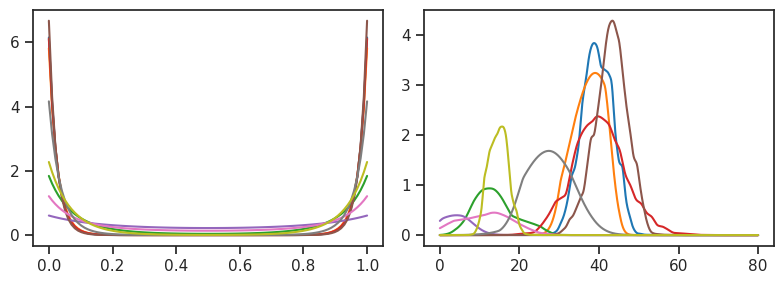

In [ ]:
tau = dataloader.dataset.laplace.tau
omega = dataloader.dataset.laplace.omega
palette = ['C' + str(x) for x in range(250000)]
n_ex = 9
for C, G in dataloader:
    fig,axs = plt.subplots(1,2,figsize=(8,3))
    for j in range(n_ex):
        axs[0].plot(tau,G[j].cpu().detach().numpy().flatten(), color=palette[j])   
        # print(np.trapz(y=G[j].cpu().detach().numpy().flatten(),x=tau)*np.pi)
        axs[1].plot(omega,C[j].cpu().detach().numpy().flatten(), color=palette[j])
        print(np.trapz(y=C[j].cpu().detach().numpy().flatten()*(( 1 - np.exp(-omega) + 1e-20 ) / ( omega + 1e-20 )),x=omega))
    plt.tight_layout()
    plt.show()

# Training the Denoiser model 
100 epochs each with 20K data-pairs (C,G).

In [ ]:
from tld.train import main

please install Weights & Biases


In [3]:
model_cfg = ModelConfig(train_config=TrainConfig(compile=False))
model = main(model_cfg)

Creating training loader:
model prep
The model has 827404 parameters


100%|██████████| 100/100 [00:21<00:00,  4.64it/s]


epoch: 1 | train_loss: 0.6701166906952858


100%|██████████| 100/100 [00:20<00:00,  4.89it/s]


epoch: 2 | train_loss: 0.4129501569271088


...

epoch: 98 | train_loss: 0.014056141683831812


100%|██████████| 100/100 [00:22<00:00,  4.48it/s]


epoch: 99 | train_loss: 0.014225980890914798


100%|██████████| 100/100 [00:22<00:00,  4.38it/s]

epoch: 100 | train_loss: 0.013907434213906526


# Inference

### creating test dataloader

In [4]:
from dataclasses import asdict
hparams = asdict(model_cfg.data_config)
random_seed = 40
bumps = Bumps(hparams=hparams, random_seed=random_seed)
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=9)
test_loader = DataLoader(dataset, batch_size=9, shuffle=False,num_workers=4) # Note: num_workers>0 to prevent the loader to create new data
for C_test, G_test in test_loader:
    C_test = C_test.view(-1,1,model_cfg.denoiser_config.x_points)
    G_test = G_test.view(-1,1,model_cfg.denoiser_config.y_points)
    print(C_test.size(),G_test.size())

torch.Size([9, 1, 1024]) torch.Size([9, 1, 99])


### generating spectra conditioned on iTCF

In [ ]:
diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
C_preds = diffuser.generate(
        labels= G_test,
        num_specs=9,
        class_guidance=1.,
        seed=2,
        n_iter=40,
        exponent=1,
        sharp_f=0.1,
        x_points=1024
    )

100%|██████████| 39/39 [00:00<00:00, 140.62it/s]


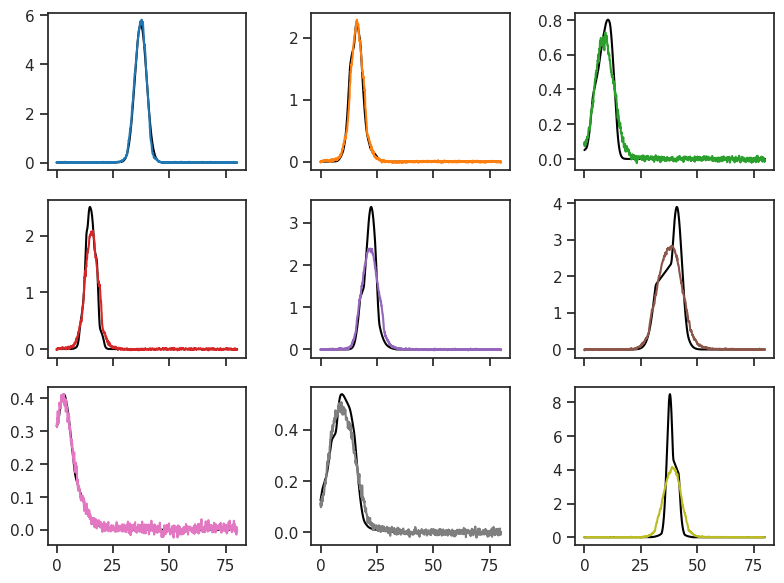

In [8]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
omega = test_loader.dataset.laplace.omega
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color='k')
    ax.plot(omega,C_preds[j].view(1024).cpu().detach().numpy(), color=palette[j])
plt.tight_layout()
plt.show()

# 3 peaks

In [3]:
model_cfg = ModelConfig(data_config=SpectralDataConfig(num_bumps_range=(1,4)),train_config=TrainConfig(compile=False,n_epoch=550))
model = main(model_cfg)

Creating training loader:
model prep
The model has 827404 parameters


100%|██████████| 100/100 [00:21<00:00,  4.60it/s]


epoch: 1 | train_loss: 0.6207374526560306


100%|██████████| 100/100 [00:21<00:00,  4.58it/s]


epoch: 2 | train_loss: 0.22057025820016862


...

epoch: 548 | train_loss: 0.009088223776780069


100%|██████████| 100/100 [00:21<00:00,  4.69it/s]


epoch: 549 | train_loss: 0.009174775257706642


100%|██████████| 100/100 [00:21<00:00,  4.73it/s]

epoch: 550 | train_loss: 0.009026074400171637


### Inference

In [ ]:
hparams = asdict(model_cfg.data_config)
random_seed = 40
bumps = Bumps(hparams=hparams, random_seed=random_seed)
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=9)
test_loader = DataLoader(dataset, batch_size=9, shuffle=False,num_workers=4) # Note: num_workers>0 to prevent the loader to create new data
for C_test, G_test in test_loader:
    C_test = C_test.view(-1,1,model_cfg.denoiser_config.x_points)
    G_test = G_test.view(-1,1,model_cfg.denoiser_config.y_points)
    print(C_test.size(),G_test.size())

torch.Size([9, 1, 1024]) torch.Size([9, 1, 99])


In [ ]:
from tld.diffusion import DiffusionGenerator
diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
C_preds_list = [diffuser.generate(
        labels= G_test,
        num_specs=9,
        class_guidance=1,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=1024
    ).view(-1,1024).cpu().detach().numpy() for i in range(40)]
C_preds_array=np.array(C_preds_list)
C_preds_mean = C_preds_array.mean(0)
C_preds_std = C_preds_array.std(0)

100%|██████████| 39/39 [00:00<00:00, 185.49it/s]


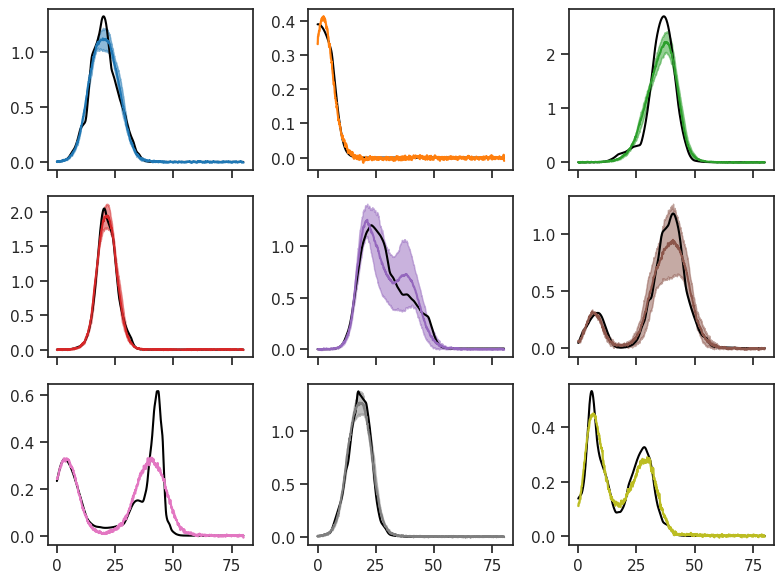

In [8]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
omega = test_loader.dataset.laplace.omega
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color='k')
    # ax.plot(omega,C_preds[j].view(1024).cpu().detach().numpy(), color=palette[j])
    ax.plot(omega,C_preds_mean[j], color=palette[j])
    ax.fill_between(omega,C_preds_mean[j]-C_preds_std[j],C_preds_mean[j]+C_preds_std[j],color=palette[j],alpha=0.5)
plt.tight_layout()
plt.show()

# 3 peacks, 10 layers

In [3]:
model_cfg = ModelConfig(
    data_config=SpectralDataConfig(num_bumps_range=(1,4)),
    denoiser_config=DenoiserConfig(n_layers=10),
    train_config=TrainConfig(compile=False, batch_size=100)
    )
model = main(model_cfg)

Creating training loader:
model prep
The model has 2457228 parameters


100%|██████████| 200/200 [00:43<00:00,  4.57it/s]


epoch: 1 | train_loss: 0.560780910924077


100%|██████████| 200/200 [00:43<00:00,  4.58it/s]


epoch: 2 | train_loss: 0.2202516420930624


...

epoch: 98 | train_loss: 0.012055638399906456


100%|██████████| 200/200 [00:50<00:00,  3.95it/s]


epoch: 99 | train_loss: 0.01133674796205014


100%|██████████| 200/200 [00:47<00:00,  4.22it/s]

epoch: 100 | train_loss: 0.010896193699445576


In [ ]:
hparams = asdict(model_cfg.data_config)
random_seed = 40
bumps = Bumps(hparams=hparams, random_seed=random_seed)
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=9)
test_loader = DataLoader(dataset, batch_size=9, shuffle=False,num_workers=4) # Note: num_workers>0 to prevent the loader to create new data
for C_test, G_test in test_loader:
    C_test = C_test.view(-1,1,model_cfg.denoiser_config.x_points)
    G_test = G_test.view(-1,1,model_cfg.denoiser_config.y_points)
    print(C_test.size(),G_test.size())

torch.Size([9, 1, 1024]) torch.Size([9, 1, 99])


In [ ]:
diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
C_preds_list = [diffuser.generate(
        labels= G_test,
        num_specs=9,
        class_guidance=1.1,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=False
    ).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list)
C_preds_mean = C_preds_array.mean(0)
C_preds_std = C_preds_array.std(0)

100%|██████████| 39/39 [00:00<00:00, 59.47it/s]


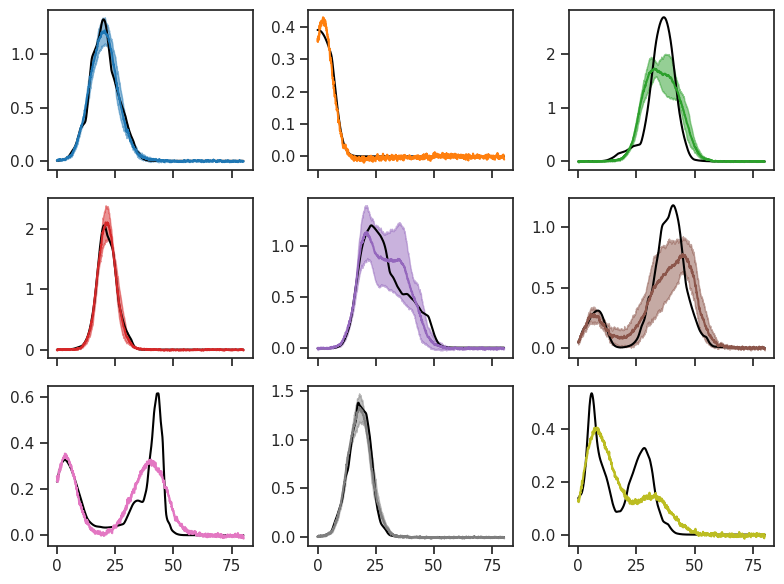

In [27]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
omega = test_loader.dataset.laplace.omega
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color='k')
    # ax.plot(omega,C_preds[j].view(1024).cpu().detach().numpy(), color=palette[j])
    ax.plot(omega,C_preds_mean[j], color=palette[j])
    ax.fill_between(omega,C_preds_mean[j]-C_preds_std[j],C_preds_mean[j]+C_preds_std[j],color=palette[j],alpha=0.5)
plt.tight_layout()
plt.show()

# 3 peacks, 12 layers, emd_dim=256

In [2]:
model_cfg = ModelConfig(
    data_config=SpectralDataConfig(num_bumps_range=(1,4)),
    denoiser_config=DenoiserConfig(n_layers=12,embed_dim=256),
    train_config=TrainConfig(compile=False, batch_size=50,n_epoch=150,use_wandb=True,save_model=True,model_name='12layers')
    )
model = main(model_cfg)

Creating training loader:
model prep


wandb: Currently logged in as: sagimeir (sagimeir-tel-aviv-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
/home/sagi/anaconda3/lib/python3.11/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(
/home/sagi/anaconda3/lib/python3.11/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


The model has 11383564 parameters


100%|██████████| 400/400 [01:25<00:00,  4.68it/s]


epoch: 1 | train_loss: 1.4709236589074135


...

100%|██████████| 400/400 [01:32<00:00,  4.33it/s]


epoch: 149 | train_loss: 0.010739405300701037


100%|██████████| 400/400 [01:31<00:00,  4.37it/s]

epoch: 150 | train_loss: 0.010579417379340157


train_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,0.01058


In [2]:
model_cfg = ModelConfig(
    data_config=SpectralDataConfig(num_bumps_range=(1,4)),
    denoiser_config=DenoiserConfig(n_layers=12,embed_dim=256),
    train_config=TrainConfig(
        compile=False, 
        batch_size=50,
        n_epoch=2,
        use_wandb=True,
        save_model=True,
        model_name='12layers',
        from_scratch = False,
        run_id = 'c1uiqdox'
        )
    )
# model = main(model_cfg)
from tld.denoiser import Denoiser
model = Denoiser(**asdict(model_cfg.denoiser_config))
model.load_state_dict(torch.load('12layers',map_location=torch.device('cuda'))["model_ema"])

<All keys matched successfully>

In [3]:
hparams = asdict(model_cfg.data_config)
random_seed = 40
bumps = Bumps(hparams=hparams, random_seed=random_seed)
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=9)
test_loader = DataLoader(dataset, batch_size=9, shuffle=False,num_workers=4) # Note: num_workers>0 to prevent the loader to create new data
for C_test, G_test in test_loader:
    # C_test = C_test.view(-1,1,model_cfg.denoiser_config.x_points)
    # G_test = G_test.view(-1,1,model_cfg.denoiser_config.y_points)
    print(C_test.size(),G_test.size())

torch.Size([9, 1, 1024]) torch.Size([9, 1, 99])


In [4]:
diffuser = DiffusionGenerator(model.to('cuda'), 'cuda', torch.float32)
C_preds_list = [diffuser.generate(
        labels= G_test.to('cuda'),
        num_specs=9,
        class_guidance=1,
        seed=i,
        n_iter=2,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=True
    ).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list)
C_preds_mean = C_preds_array.mean(0)
C_preds_std = C_preds_array.std(0)

100%|██████████| 1/1 [00:00<00:00, 206.62it/s]


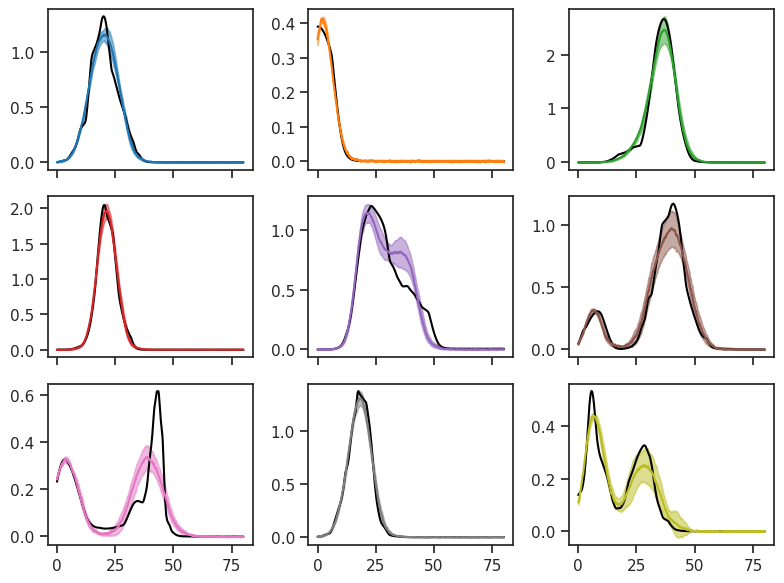

In [5]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
omega = test_loader.dataset.laplace.omega
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color='k')
    # ax.plot(omega,C_preds[j].view(1024).cpu().detach().numpy(), color=palette[j])
    ax.plot(omega,C_preds_mean[j], color=palette[j])
    ax.fill_between(omega,C_preds_mean[j]-C_preds_std[j],C_preds_mean[j]+C_preds_std[j],color=palette[j],alpha=0.5)
plt.tight_layout()
plt.show()

## Real Data Inference

In [6]:
#params
kB = 3.1668114E-6  # in Hartree/K
c = 2.99792458E10  # speed of light in cm/s
s_in_t_au = 2.4188843265857E-17  # 1 time a.u. in s

T = 14.0  # in K

b = 1 / (kB * T)
print('beta is ' + str(b))


# rabani input:
Nbeads = 219
Natoms = 180
tau = test_loader.dataset.laplace.tau
# omega_dummy = np.linspace(omega_range[0], omega_range[1], Ng_w)

G_rabani = np.load('data/barak/G_Rabani_' + str(T) + 'K_' + str(Natoms) + 'p.npy')
tau_PIMD = G_rabani[0]
G_rabani = G_rabani[1]

# adds points to G
G_rabani_interp = np.interp(tau, tau_PIMD, G_rabani)
Norm_rabani = np.trapz(G_rabani_interp,tau)*np.pi
G_rabani_interp = G_rabani_interp / Norm_rabani

G_anal_tensor = torch.Tensor(G_rabani_interp)

# rabani output:
import pandas as pd
rabani_data = pd.read_csv("data/Rabani_D_w_14K.csv", sep=",", header=None)
rabani_data_w, rabani_data_D = rabani_data[0].values,rabani_data[1].values
rabani_data_w *= ( 2 * np.pi * c * s_in_t_au * b ) # now omega unitless



# # PIMD with I-pi input:
Nbeads = 50
df=pd.read_csv('/home/sagi/Desktop/parahydrogen/pH2_for_Amit/G_14K_50beads_180p_ipi_sym.csv')
_, G_rabani = df['tau'].values,df['G'].values

# # interpolate - adding points to G
tau_PIMD = np.linspace(0,1,Nbeads+1)
G_rabani_interp_2 = np.interp(tau, tau_PIMD, G_rabani)
Correct_norm = np.trapz(G_rabani_interp_2,tau)*np.pi
G_rabani_interp_2 = G_rabani_interp_2 / Correct_norm 

G_anal_tensor_2 = torch.Tensor(G_rabani_interp_2)

beta is 22555.360078775586


In [7]:
diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
C_preds_list_rabani = [diffuser.generate(
        labels= G_anal_tensor.view(1,1,-1),
        num_specs=1,
        class_guidance=1.,
        seed=i,
        n_iter=2,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=True
    ).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list_rabani)
C_preds_mean_rabani = C_preds_array.mean(0)
C_preds_std_rabani = C_preds_array.std(0)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 241.72it/s]


In [8]:
diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
C_preds_list_rabani = [diffuser.generate(
        labels= G_anal_tensor_2.view(1,1,-1),
        num_specs=1,
        class_guidance=1.,
        seed=i,
        n_iter=2,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=True
    ).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list_rabani)
C_preds_mean_rabani_2 = C_preds_array.mean(0)
C_preds_std_rabani_2 = C_preds_array.std(0)

100%|██████████| 1/1 [00:00<00:00, 135.89it/s]


In [12]:
mass=2.01588 # gram/mol
hbar = 1.054571817 * 1E-34 # J * sec = kg * m^2 /sec
hbar *= 1E+20 # kg * angstrom^2 /sec
hbar *= 1E-12 # kg * angstrom^2 /ps
mass /= (1000 * 6.02214076 * 1E+23) # kg
renorm_factor = hbar*3*np.pi/mass

0.5625256056847002
0.5937535564119555
0.2881096360834827


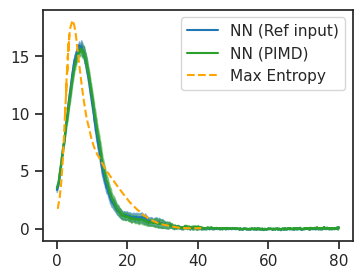

In [13]:
fig,ax = plt.subplots(figsize=(4,3))
ax.plot(omega,renorm_factor*C_preds_mean_rabani[0],label='NN (Ref input)',color='tab:blue')
ax.fill_between(omega,renorm_factor*(C_preds_mean_rabani[0]-C_preds_std_rabani[0]),renorm_factor*(C_preds_mean_rabani[0]+C_preds_std_rabani[0]),color='tab:blue',alpha=0.5)
print(renorm_factor*C_preds_mean_rabani[0][0]/6)
ax.plot(omega,renorm_factor*C_preds_mean_rabani_2[0],color='tab:green',label='NN (PIMD)')
ax.fill_between(omega,renorm_factor*(C_preds_mean_rabani_2[0]-C_preds_std_rabani_2[0]),renorm_factor*(C_preds_mean_rabani_2[0]+C_preds_std_rabani_2[0]),color='tab:green',alpha=0.5)
print(renorm_factor*C_preds_mean_rabani_2[0][0]/6)
ax.plot(rabani_data_w,rabani_data_D*6,'--',color='orange',label='Max Entropy')
print(rabani_data_D[0])
ax.legend()

In [ ]:
Nbeads = 32
df=pd.read_csv('/home/sagi/Desktop/water/G_300K_32beads_sym.csv')
_, G_water = df['tau'].values,df['G'].values

G_water_interp = np.interp(tau, np.linspace(0,1,Nbeads+1), G_water)
Norm_water = np.trapz(G_water_interp,tau)*np.pi
G_water_interp = G_water_interp / Norm_water

G_water_tensor = torch.Tensor(G_water_interp)

velFT = np.loadtxt('/home/sagi/Desktop/water/1bead/nve1/nve_facf.data', usecols=(0,1))
velFT = velFT[velFT[:,0] * 219474<=8000]
fac = (1/kB/300 * velFT[:,0]+ 1E-30) / (1-np.exp(-1/kB/300*velFT[:,0]) + 1E-30)
water_data_w, water_nve_D = velFT[:,0]* 219474 * ( 2 * np.pi * c * s_in_t_au /kB/300 ), velFT[:,1]*fac

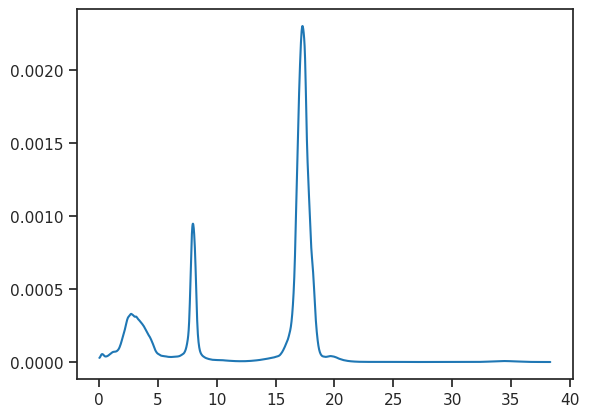

In [33]:
plt.plot(water_data_w,water_nve_D)

In [36]:
diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
C_preds_list_water = [diffuser.generate(
        labels= G_water_tensor.view(1,1,-1),
        num_specs=1,
        class_guidance=1.,
        seed=i,
        n_iter=400,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=True
    ).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list_water)
C_preds_mean_water = C_preds_array.mean(0)
C_preds_std_water = C_preds_array.std(0)

100%|██████████| 399/399 [00:02<00:00, 162.25it/s]


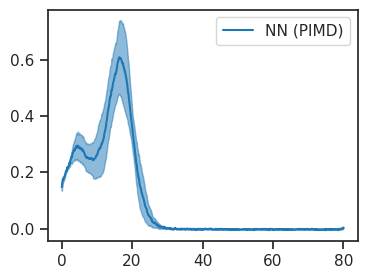

In [37]:
fig,ax = plt.subplots(figsize=(4,3))
ax.plot(omega,C_preds_mean_water[0],label='NN (PIMD)',color='tab:blue')
ax.fill_between(omega,(C_preds_mean_water[0]-C_preds_std_water[0]),(C_preds_mean_water[0]+C_preds_std_water[0]),color='tab:blue',alpha=0.5)
# print(renorm_factor*C_preds_mean_rabani[0][0]/6)
# ax.plot(omega,renorm_factor*C_preds_mean_rabani_2[0],color='tab:green',label='NN (PIMD)')
# ax.fill_between(omega,renorm_factor*(C_preds_mean_rabani_2[0]-C_preds_std_rabani_2[0]),renorm_factor*(C_preds_mean_rabani_2[0]+C_preds_std_rabani_2[0]),color='tab:green',alpha=0.5)
# print(renorm_factor*C_preds_mean_rabani_2[0][0]/6)
# ax.plot(rabani_data_w,rabani_data_D*6,'--',color='orange',label='Max Entropy')
# print(rabani_data_D[0])
ax.legend()

# Data Normalization with respect to G(0)

In [44]:
model_cfg = ModelConfig(
    data_config=SpectralDataConfig(num_bumps_range=(1,4)),
    denoiser_config=DenoiserConfig(n_layers=12,embed_dim=256),
    train_config=TrainConfig(
        compile=False, 
        lr=3e-5,
        batch_size=50,
        n_epoch=150,
        use_wandb=True,
        save_model=True,
        model_name='NormG_12layers')
    )
model = main(model_cfg)

Creating training loader:
model prep


/home/sagi/anaconda3/lib/python3.11/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(
/home/sagi/anaconda3/lib/python3.11/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


The model has 11383564 parameters


100%|██████████| 400/400 [01:24<00:00,  4.75it/s]


epoch: 1 | train_loss: 0.1592415854986757


...

100%|██████████| 400/400 [01:21<00:00,  4.88it/s]


epoch: 149 | train_loss: 0.0012056526250671595


100%|██████████| 400/400 [01:22<00:00,  4.87it/s]

epoch: 150 | train_loss: 0.0011823584650119301


train_loss,█▆▆▅▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,0.00118


In [2]:
model_cfg = ModelConfig(
    data_config=SpectralDataConfig(num_bumps_range=(1,4)),
    denoiser_config=DenoiserConfig(n_layers=12,embed_dim=256),
    train_config=TrainConfig(
        compile=False,
        lr=3e-5, 
        batch_size=50,
        n_epoch=3000,
        use_wandb=True,
        save_model=True,
        model_name='NormG_12layers',
        from_scratch = False,
        run_id = 'atccoycc'
        )
    )
model = main(model_cfg)

Creating training loader:
Loading Model:
model prep


wandb: Currently logged in as: sagimeir (sagimeir-tel-aviv-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
/home/sagi/anaconda3/lib/python3.11/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(
/home/sagi/anaconda3/lib/python3.11/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


The model has 11383564 parameters


100%|██████████| 400/400 [01:29<00:00,  4.48it/s]


epoch: 1 | train_loss: 0.0007855098968138918


...

100%|██████████| 400/400 [01:22<00:00,  4.84it/s]


epoch: 2999 | train_loss: 0.0006044561292947037


100%|██████████| 400/400 [01:22<00:00,  4.85it/s]

epoch: 3000 | train_loss: 0.0005970144055027049


train_loss,██▆▄▄▃▃▃▄▃▃▂▂▃▃▂▃▂▃▂▃▁▂▂▂▂▂▂▂▂▂▃▁▃▂▂▂▂▂▂
train_loss,0.0006


In [55]:
hparams = asdict(model_cfg.data_config)
random_seed = 40
bumps = Bumps(hparams=hparams, random_seed=random_seed)
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=9)
test_loader = DataLoader(dataset, batch_size=9, shuffle=False,num_workers=4) # Note: num_workers>0 to prevent the loader to create new data
for C_test, G_test in test_loader:
    C_test = C_test.view(-1,1,model_cfg.denoiser_config.x_points)
    G_test = G_test.view(-1,1,model_cfg.denoiser_config.y_points)
    print(C_test.size(),G_test.size())

torch.Size([9, 1, 1024]) torch.Size([9, 1, 99])


In [ ]:
diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
C_preds_list = [diffuser.generate(
        labels= G_test,
        num_specs=9,
        class_guidance=1.,
        seed=i,
        exponent=1,
        n_iter=40,
        x_points=1024,
        use_ddpm_plus=True
    ).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list)
C_preds_mean = C_preds_array.mean(0)
C_preds_std = C_preds_array.std(0)

100%|██████████| 39/39 [00:01<00:00, 23.84it/s]


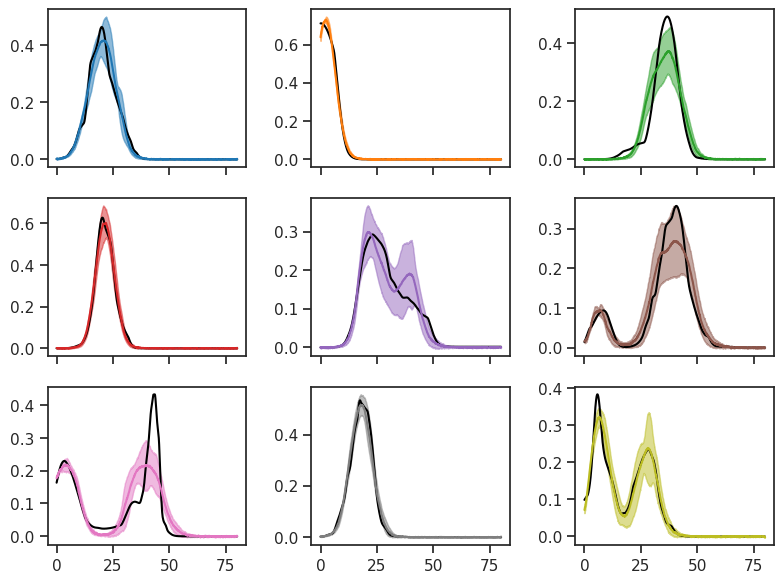

In [198]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
omega = test_loader.dataset.laplace.omega
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color='k')
    # ax.plot(omega,C_preds[j].view(1024).cpu().detach().numpy(), color=palette[j])
    ax.plot(omega,C_preds_mean[j], color=palette[j])
    ax.fill_between(omega,C_preds_mean[j]-C_preds_std[j],C_preds_mean[j]+C_preds_std[j],color=palette[j],alpha=0.5)
    # [ax.plot(omega,C_preds_array[s][j], color=palette[j],alpha=0.4,linewidth=0.5) for s in range(20)]
plt.tight_layout()
plt.show()

In [ ]:
diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
C_preds_list = [diffuser.generate(
        labels= G_test,
        num_specs=9,
        class_guidance=1.,
        seed=i,
        exponent=1,
        n_iter=2,
        x_points=1024,
        use_ddpm_plus=False
    ).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list)
C_preds_mean = C_preds_array.mean(0)
C_preds_std = C_preds_array.std(0)

100%|██████████| 1/1 [00:00<00:00, 244.00it/s]


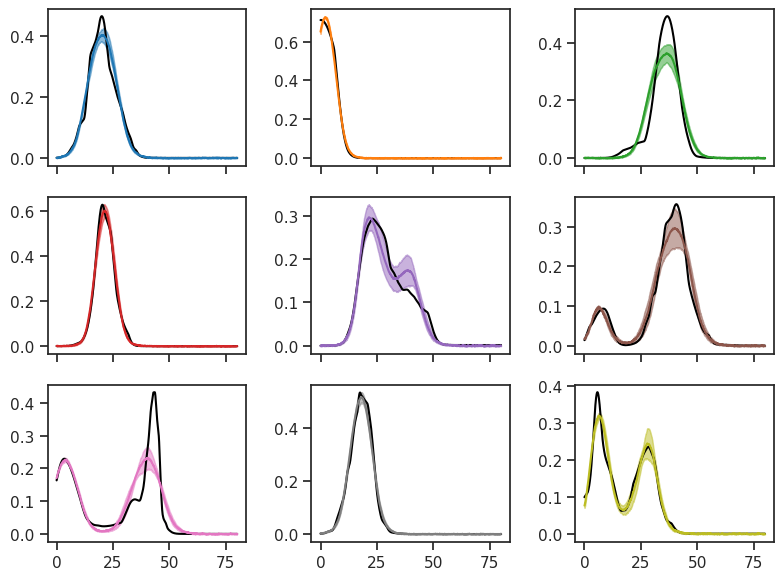

In [210]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
omega = test_loader.dataset.laplace.omega
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color='k')
    # ax.plot(omega,C_preds[j].view(1024).cpu().detach().numpy(), color=palette[j])
    ax.plot(omega,C_preds_mean[j], color=palette[j])
    ax.fill_between(omega,C_preds_mean[j]-C_preds_std[j],C_preds_mean[j]+C_preds_std[j],color=palette[j],alpha=0.5)
    # [ax.plot(omega,C_preds_array[s][j], color=palette[j],alpha=0.4,linewidth=0.5) for s in range(20)]
plt.tight_layout()
plt.show()

In [225]:
model.eval()
generator = torch.Generator(device='cuda')
generator.manual_seed(10)

C_preds_list = [model(
    torch.randn(9,1,1024,dtype=torch.float32,device='cuda',generator=generator),
     torch.full((9, 1), 0.99).to('cuda'),
    G_test.to('cuda')
    ).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list)
C_preds_mean = C_preds_array.mean(0)
C_preds_std = C_preds_array.std(0)

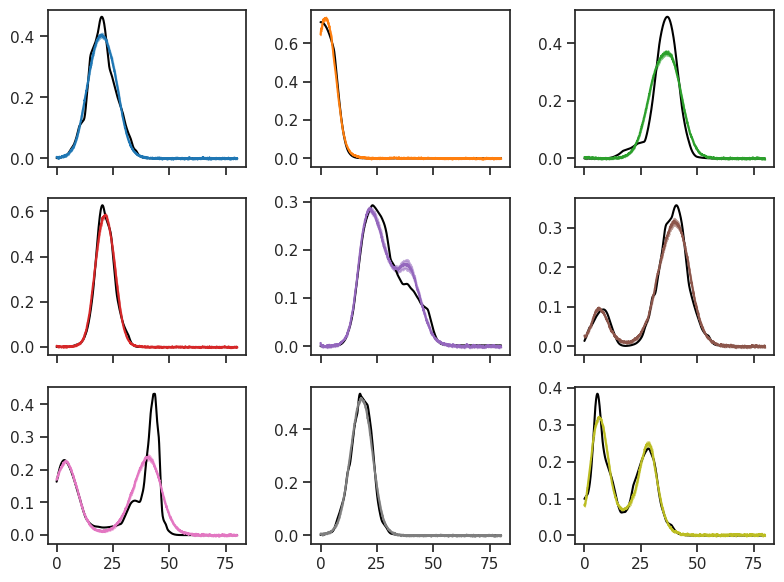

In [226]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
omega = test_loader.dataset.laplace.omega
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color='k')
    ax.plot(omega,C_preds_mean[j], color=palette[j])
    ax.fill_between(omega,C_preds_mean[j]-C_preds_std[j],C_preds_mean[j]+C_preds_std[j],color=palette[j],alpha=0.5)
plt.tight_layout()
plt.show()

## Real Data Inference

In [ ]:
#params
kB = 3.1668114E-6  # in Hartree/K
c = 2.99792458E10  # speed of light in cm/s
s_in_t_au = 2.4188843265857E-17  # 1 time a.u. in s

T = 14.0  # in K

b = 1 / (kB * T)
print('beta is ' + str(b))


# rabani input:
Nbeads = 219
Natoms = 180
tau = test_loader.dataset.laplace.tau
# omega_dummy = np.linspace(omega_range[0], omega_range[1], Ng_w)

G_rabani = np.load('data/barak/G_Rabani_' + str(T) + 'K_' + str(Natoms) + 'p.npy')
tau_PIMD = G_rabani[0]
G_rabani = G_rabani[1]

# adds points to G
G_rabani_interp = np.interp(tau, tau_PIMD, G_rabani)
Norm_rabani = G_rabani_interp[0]
G_rabani_interp = 2 * G_rabani_interp / Norm_rabani - 1

G_anal_tensor = torch.Tensor(G_rabani_interp)

# rabani output:
import pandas as pd
rabani_data = pd.read_csv("data/Rabani_D_w_14K.csv", sep=",", header=None)
rabani_data_w, rabani_data_D = rabani_data[0].values,rabani_data[1].values
rabani_data_w *= ( 2 * np.pi * c * s_in_t_au * b ) # now omega unitless



# # PIMD with I-pi input:
Nbeads = 50
df=pd.read_csv('/home/sagi/Desktop/parahydrogen/pH2_for_Amit/G_14K_50beads_180p_ipi_sym.csv')
_, G_rabani = df['tau'].values,df['G'].values

# # interpolate - adding points to G
tau_PIMD = np.linspace(0,1,Nbeads+1)
G_rabani_interp_2 = np.interp(tau, tau_PIMD, G_rabani)
Correct_norm = G_rabani_interp_2[0]
G_rabani_interp_2 = 2 * G_rabani_interp_2 / Correct_norm  - 1

G_anal_tensor_2 = torch.Tensor(G_rabani_interp_2)

beta is 22555.360078775586


In [ ]:
# mass=2.01588 # gram/mol
# def spec_renorm(omega,spec,mass=mass):
#     hbar = 1.054571817 * 1E-34 # J * sec = kg * m^2 /sec
#     hbar *= 1E+20 # kg * angstrom^2 /sec
#     hbar *= 1E-12 # kg * angstrom^2 /ps
#     mass /= (1000 * 6.02214076 * 1E+23) # kg
#     epsilon = 1E-50

#     Area = np.trapz(y=spec*( (1-np.exp(-omega) + epsilon ) / (omega + epsilon)  ), x=omega)
#     return spec/Area/mass*hbar*3*np.pi

In [200]:
diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
C_preds_list_rabani = [diffuser.generate(
        labels= G_anal_tensor.view(1,1,-1),
        num_specs=1,
        class_guidance=1.5,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=True
    ).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list_rabani)
C_preds_mean_rabani = C_preds_array.mean(0)
C_preds_std_rabani = C_preds_array.std(0)

100%|██████████| 39/39 [00:00<00:00, 158.81it/s]


In [207]:
diffuser = DiffusionGenerator(model, 'cuda', torch.float32)
C_preds_list_rabani = [diffuser.generate(
        labels= G_anal_tensor_2.view(1,1,-1),
        num_specs=1,
        class_guidance=1.,
        seed=i,
        n_iter=40,
        exponent=1,
        x_points=1024,
        use_ddpm_plus=True
    ).view(-1,1024).cpu().detach().numpy() for i in range(20)]
C_preds_array=np.array(C_preds_list_rabani)
C_preds_mean_rabani_2 = C_preds_array.mean(0)
C_preds_std_rabani_2 = C_preds_array.std(0)

100%|██████████| 39/39 [00:00<00:00, 161.07it/s]


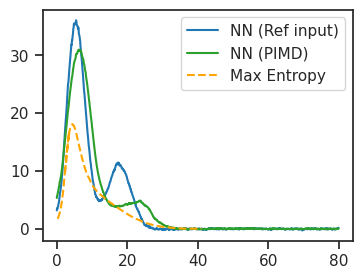

In [208]:
fig,ax = plt.subplots(figsize=(4,3))

ax.plot(omega,C_preds_mean_rabani[0]*Correct_norm*1e-24,label='NN (Ref input)',color='tab:blue')
# ax.fill_between(omega,C_preds_mean_rabani[0]-C_preds_std_rabani[0],C_preds_mean_rabani[0]+C_preds_std_rabani[0],color='tab:blue',alpha=0.5)
ax.plot(omega,C_preds_mean_rabani_2[0]*Correct_norm*1e-24,color='tab:green',label='NN (PIMD)')
# ax.fill_between(omega,C_preds_mean_rabani_2[0]-C_preds_std_rabani_2[0],C_preds_mean_rabani_2[0]+C_preds_std_rabani_2[0],color='tab:green',alpha=0.5)
ax.plot(rabani_data_w,rabani_data_D*6,'--',color='orange',label='Max Entropy')
ax.legend()

# Old tests of code

In [4]:
from tld.configs import ModelConfig
from dataclasses import asdict
cfg = ModelConfig()
asdict(cfg.data_config)

{'omega_domain': (0, 80.0),
 'num_bumps_range': (1, 2),
 'bump_widths_fraction_range': (0.13, 0.45),
 'bump_centers_fraction_range': (0.0, 0.6)}

In [4]:
from tld.denoiser import Denoiser
from tld.configs import DenoiserConfig, TrainConfig
from accelerate import Accelerator
from dataclasses import asdict
model_config = DenoiserConfig()
train_config = TrainConfig()
asdict(model_config), asdict(train_config)

({'x_points': 1024,
  'noise_embed_dims': 256,
  'patch_size': 2,
  'embed_dim': 128,
  'dropout': 0,
  'n_layers': 3,
  'y_points': 99,
  'mlp_multiplier': 4},
 {'batch_size': 128,
  'lr': 0.0003,
  'n_epoch': 100,
  'alpha': 0.999,
  'from_scratch': True,
  'beta_a': 1,
  'beta_b': 2.5,
  'save_and_eval_every_iters': 1000,
  'run_id': '',
  'model_name': '',
  'compile': True,
  'save_model': True,
  'use_wandb': True})

In [5]:
model = Denoiser(**asdict(model_config))
model

Denoiser(
  (fourier_feats): Sequential(
    (0): SinusoidalEmbedding()
    (1): Linear(in_features=256, out_features=128, bias=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
  (denoiser_trans_block): DenoiserTransBlock(
    (patchify_and_embed): Sequential(
      (0): Conv1d(1, 2, kernel_size=(2,), stride=(2,))
      (1): Rearrange('bs d l -> bs l d')
      (2): LayerNorm((2,), eps=1e-05, elementwise_affine=True)
      (3): Linear(in_features=2, out_features=128, bias=True)
      (4): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (rearrange2): Rearrange('b l (c p) -> b c (l p)', l=512, p=2)
    (pos_embed): Embedding(512, 128)
    (decoder_blocks): ModuleList(
      (0-2): 3 x DecoderBlock(
        (self_attention): SelfAttention(
          (qkv_linear): Linear(in_features=128, out_features=384, bias=False)
          (mha): MHAttention()
        )
        (cross_attention): CrossAttention(
          (kv_linea

In [103]:
sum(p.numel() for p in model.parameters() if p.requires_grad)

827404

In [7]:
noise_level = torch.tensor(np.random.beta(train_config.beta_a, train_config.beta_b, len(C))).float()
model(C.view(-1,1,1024), noise_level.view(-1,1), G.view(-1,1,99))

tensor([[[-2.7043, -0.0301, -1.5757,  ..., -0.2387, -2.2387, -0.0061]],

        [[-3.4934,  0.2310, -2.2708,  ..., -0.0492, -2.9878,  0.2742]],

        [[-1.8055,  0.9857, -0.4098,  ...,  0.3773, -2.1370,  0.7689]],

        ...,

        [[ 0.1108,  0.6568,  1.3870,  ..., -0.7387, -1.7719, -0.3265]],

        [[-0.6259,  0.9668,  0.5824,  ..., -0.2802, -2.4489,  0.1626]],

        [[-3.2578,  0.6745, -1.9873,  ...,  0.3451, -2.6918,  0.7729]]],
       grad_fn=<ReshapeAliasBackward0>)

In [ ]:
accelerator = Accelerator(mixed_precision="fp16")
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=train_config.lr)
global_step = 0
accelerator.print("model prep")
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=20000)
train_loader = DataLoader(dataset, batch_size=200, shuffle=False,num_workers=0)
model, train_loader, optimizer = accelerator.prepare(model, train_loader, optimizer)
# def update_ema(ema_model: nn.Module, model: nn.Module, alpha: float = 0.999):
#     with torch.no_grad():
#         for ema_param, model_param in zip(ema_model.parameters(), model.parameters()):
#             ema_param.data.mul_(alpha).add_(model_param.data, alpha=1 - alpha)


model prep


In [45]:
epoch_loss=[]
for i in range(1, train_config.n_epoch + 1):
    # accelerator.print(f"epoch: {i}")
    batch_loss=[]
    for x, y in train_loader:
        x = x.view(-1,1,model_config.x_points) 

        noise_level = torch.tensor(
            np.random.beta(train_config.beta_a, train_config.beta_b, len(x)), device=accelerator.device
        )
        signal_level = 1 - noise_level
        noise = torch.randn_like(x)

        x_noisy = noise_level.view(-1, 1, 1) * noise + signal_level.view(-1, 1, 1) * x 

        x_noisy = x_noisy.float()
        noise_level = noise_level.float()
        label = y.view(-1,1,model_config.y_points)

        prob = 0.15
        mask = torch.rand(y.size(0), device=accelerator.device) < prob
        label[mask] = 0  # OR replacement_vector
        model.train()
        with accelerator.accumulate():
            ###train loop:
            optimizer.zero_grad()

            pred = model(x_noisy, noise_level.view(-1, 1), label)
            loss = loss_fn(pred, x)
            # accelerator.log({"train_loss": loss.item()}, step=global_step)
            accelerator.backward(loss)
            optimizer.step()
            batch_loss.append(loss.item())
        global_step += 1
    ep_loss = np.mean(batch_loss)
    epoch_loss.append(ep_loss)
    accelerator.print(f"epoch: {i} | train_loss: {ep_loss}")
accelerator.end_training()

epoch: 1 | train_loss: 0.10562033995985985
epoch: 2 | train_loss: 0.07652047485113143
epoch: 3 | train_loss: 0.06684779800474644
epoch: 4 | train_loss: 0.05936000391840935
epoch: 5 | train_loss: 0.051918480582535266
epoch: 6 | train_loss: 0.04969190858304501
epoch: 7 | train_loss: 0.045752718821167944
epoch: 8 | train_loss: 0.04255330314859748
epoch: 9 | train_loss: 0.040521764811128375
epoch: 10 | train_loss: 0.03981486590579152
epoch: 11 | train_loss: 0.035220452640205624
epoch: 12 | train_loss: 0.03535318968817592
epoch: 13 | train_loss: 0.034540420845150945
epoch: 14 | train_loss: 0.03366084823384881
epoch: 15 | train_loss: 0.030905584506690502
epoch: 16 | train_loss: 0.03072099506855011
epoch: 17 | train_loss: 0.03041799835860729
epoch: 18 | train_loss: 0.029164901375770567
epoch: 19 | train_loss: 0.02899061279371381
epoch: 20 | train_loss: 0.026495533753186463
epoch: 21 | train_loss: 0.027744460180401803
epoch: 22 | train_loss: 0.026289788857102394
epoch: 23 | train_loss: 0.02753

In [50]:
dataset = OnTheFlyDataset(bumps=bumps,dataset_size=9)
test_loader = DataLoader(dataset, batch_size=9, shuffle=False,num_workers=4)
for C_test, G_test in test_loader:
    C_test = C_test.view(-1,1,model_config.x_points)
    G_test = G_test.view(-1,1,model_config.y_points)
    print(C_test.size(),G_test.size())

torch.Size([9, 1, 1024]) torch.Size([9, 1, 99])


In [ ]:
from tld.diffusion import DiffusionGenerator

In [57]:
from dataclasses import dataclass, asdict
@dataclass
class DiffusionGenerator:
    model: Denoiser
    # vae: AutoencoderKL
    device: torch.device
    model_dtype: torch.dtype = torch.float32

    @torch.no_grad()
    def generate(
        self,
        labels: torch.Tensor,  # embeddings to condition on
        n_iter: int = 30,
        num_specs: int = 16,
        class_guidance: float = 3,
        seed: int = 10,
        scale_factor: int = 8,  # latent scaling before decoding - should be ~ std of latent space
        x_points: int = 1024,  # 
        sharp_f: float = 0.1,
        bright_f: float = 0.1,
        exponent: float = 1,
        seeds: torch.Tensor | None = None,
        noise_levels=None,
        use_ddpm_plus: bool = True,
    ):
        """Generate images via reverse diffusion.
        if use_ddpm_plus=True uses Algorithm 2 DPM-Solver++(2M) here: https://arxiv.org/pdf/2211.01095.pdf
        else use ddim with alpha = 1-sigma
        """
        if noise_levels is None:
            noise_levels = (1 - torch.pow(torch.arange(0, 1, 1 / n_iter), exponent)).tolist()
        noise_levels[0] = 0.99

        if use_ddpm_plus:
            lambdas = [np.log((1 - sigma) / sigma) for sigma in noise_levels]  # log snr
            hs = [lambdas[i] - lambdas[i - 1] for i in range(1, len(lambdas))]
            rs = [hs[i - 1] / hs[i] for i in range(1, len(hs))]

        x_t = self.initialize_spectrum(seeds, num_specs, x_points, seed)

        labels = torch.cat([labels, torch.zeros_like(labels)])
        self.model.eval()

        x0_pred_prev = None

        for i in range(len(noise_levels) - 1):
            curr_noise, next_noise = noise_levels[i], noise_levels[i + 1]

            x0_pred = self.pred_spec(x_t, labels, curr_noise, class_guidance)

            if x0_pred_prev is None:
                x_t = ((curr_noise - next_noise) * x0_pred + next_noise * x_t) / curr_noise
            else:
                if use_ddpm_plus:
                    # x0_pred is a combination of the two previous x0_pred:
                    D = (1 + 1 / (2 * rs[i - 1])) * x0_pred - (1 / (2 * rs[i - 1])) * x0_pred_prev
                else:
                    # ddim:
                    D = x0_pred

                x_t = ((curr_noise - next_noise) * D + next_noise * x_t) / curr_noise

            x0_pred_prev = x0_pred

        x0_pred = self.pred_spec(x_t, labels, next_noise, class_guidance)

        # shifting latents works a bit like an image editor:
        # x0_pred[:, 3, :, :] += sharp_f
        # x0_pred[:, 0, :, :] += bright_f

        # x0_pred_img = self.vae.decode((x0_pred * scale_factor).to(self.model_dtype))[0].cpu()
        return x0_pred

    def pred_spec(self, noisy_spec, labels, noise_level, class_guidance):
        num_specs = noisy_spec.size(0)
        noises = torch.full((2 * num_specs, 1), noise_level)
        x0_pred = self.model(
            torch.cat([noisy_spec, noisy_spec]),
            noises.to(self.device, self.model_dtype),
            labels.to(self.device, self.model_dtype),
        )
        x0_pred = self.apply_classifier_free_guidance(x0_pred, num_specs, class_guidance)
        return x0_pred

    def initialize_spectrum(self, seeds, num_specs, x_points, seed):
        """Initialize the seed tensor."""
        if seeds is None:
            generator = torch.Generator(device=self.device)
            generator.manual_seed(seed)
            return torch.randn(
                num_specs,
                self.model.n_channels,
                x_points,
                # img_size,
                dtype=self.model_dtype,
                device=self.device,
                generator=generator,
            )
        else:
            return seeds.to(self.device, self.model_dtype)

    def apply_classifier_free_guidance(self, x0_pred, num_specs, class_guidance):
        """Apply classifier-free guidance to the predictions."""
        x0_pred_label, x0_pred_no_label = x0_pred[:num_specs], x0_pred[num_specs:]
        return class_guidance * x0_pred_label + (1 - class_guidance) * x0_pred_no_label



In [58]:
diffuser = DiffusionGenerator(model, 'cuda', torch.float32)

In [ ]:
C_preds = diffuser.generate(
        labels= G_test,
        num_specs=9,
        class_guidance=1.,
        seed=2,
        n_iter=40,
        exponent=1,
        sharp_f=0.1,
        x_points=1024
    )

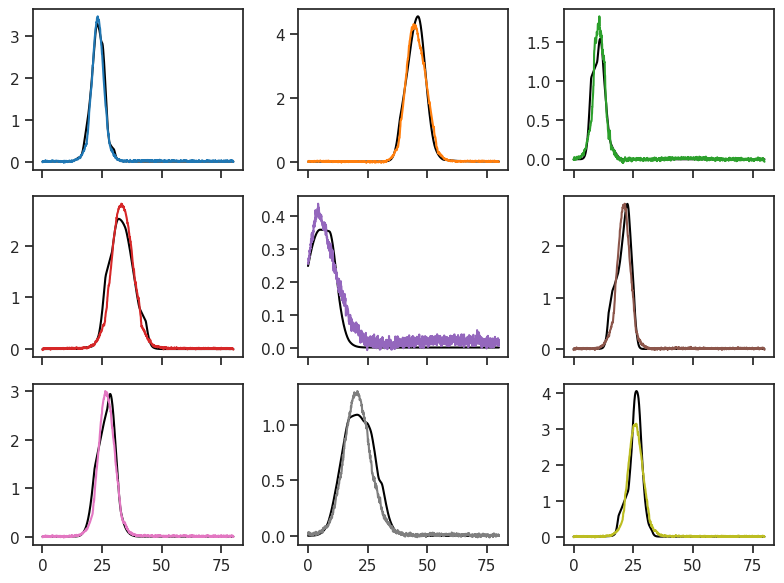

In [97]:
fig,axs = plt.subplots(3,3,figsize=(8,6),sharex=True,sharey=False)
palette = ['C' + str(x) for x in range(250000)]
n_ex=9
omega = test_loader.dataset.laplace.omega
for j in range(n_ex):
    ax = axs.flatten()[j]
    ax.plot(omega,C_test[j].view(1024).cpu().detach().numpy(), color='k')
    ax.plot(omega,C_preds[j].view(1024).cpu().detach().numpy(), color=palette[j])
plt.tight_layout()
plt.show()

In [73]:
label = model.label_proj(G.view(-1,1,99)).unsqueeze(1)

In [74]:
label.shape

torch.Size([9, 1, 1, 128])

In [76]:
noise_level = model.fourier_feats(noise_level.view(-1,1)).unsqueeze(1)

In [77]:
noise_level.shape

torch.Size([9, 1, 128])

In [70]:
model.fourier_feats(noise_level.view(-1,1))

tensor([[ 0.0897, -0.0340,  0.1545,  ..., -0.0550,  0.0520, -0.1123],
        [ 0.0319, -0.2856,  0.2196,  ..., -0.0257,  0.1148, -0.1378],
        [ 0.0580,  0.0270,  0.0509,  ..., -0.0951, -0.0864, -0.1435],
        ...,
        [-0.0673, -0.0743,  0.4017,  ..., -0.0058,  0.0174, -0.0797],
        [ 0.0546,  0.0622, -0.0828,  ...,  0.0549, -0.1178, -0.3157],
        [ 0.0651, -0.1159, -0.0824,  ..., -0.0234,  0.0705, -0.2714]],
       grad_fn=<AddmmBackward0>)